In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import hashlib
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchvision
from PIL import Image
from torchvision.datasets import EuroSAT

PROJECT_ROOT = Path(
    r"C:\Users\comviva\Documents\Eurosat_calibrated"
)
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

for directory in [DATA_ROOT, REPORTS_DIR, FIGURES_DIR, SPLITS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

dataset = EuroSAT(root=str(DATA_ROOT), download=True)

print("Images:", len(dataset))
print("Classes:", dataset.classes)
print("Working directory:", Path.cwd())

Images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Working directory: C:\Users\comviva


In [2]:
targets = np.asarray(dataset.targets) 
counts = Counter(targets)

class_distribution = pd.DataFrame({
    "class_index" : range(len(dataset.classes)),
    "class_name": dataset.classes,
    "count": [counts[index] for index in range(len(dataset.classes))],
})

class_distribution["percentage"] = (
    100 * class_distribution["count"] / len(dataset)
)

In [3]:
largest_class = class_distribution["count"].max() #Maxmimum number of Images from a single class
smallest_class = class_distribution["count"].min() # Minimum number of Images from a single class

imbalance_ratio = largest_class / smallest_class # Ratio between largest class and smallest class 

print(f"Largest class: {largest_class}")
print(f"Smallest class: {smallest_class}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Largest class: 3000
Smallest class: 2000
Imbalance ratio: 1.50:1


In [4]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=class_distribution,
    x="class_name",
    y="count",
    color="steelblue",
    ax=ax,
)

ax.tick_params(axis="x", rotation=45)
ax.set_title("EuroSAT RGB class distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of images")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close(fig)

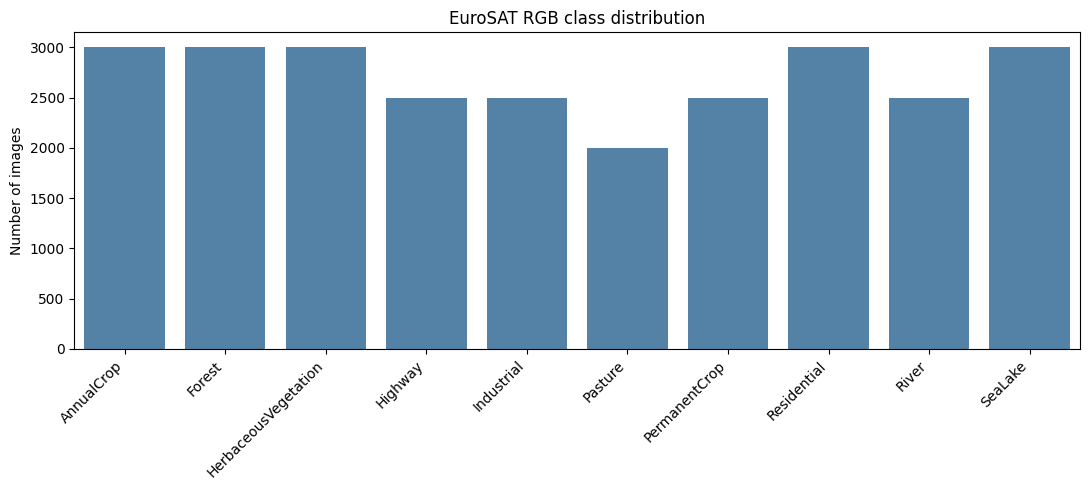

In [5]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=class_distribution,
    x="class_name",
    y="count",
    color="steelblue",
)

plt.xticks(rotation=45, ha="right")
plt.title("EuroSAT RGB class distribution")
plt.xlabel("")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

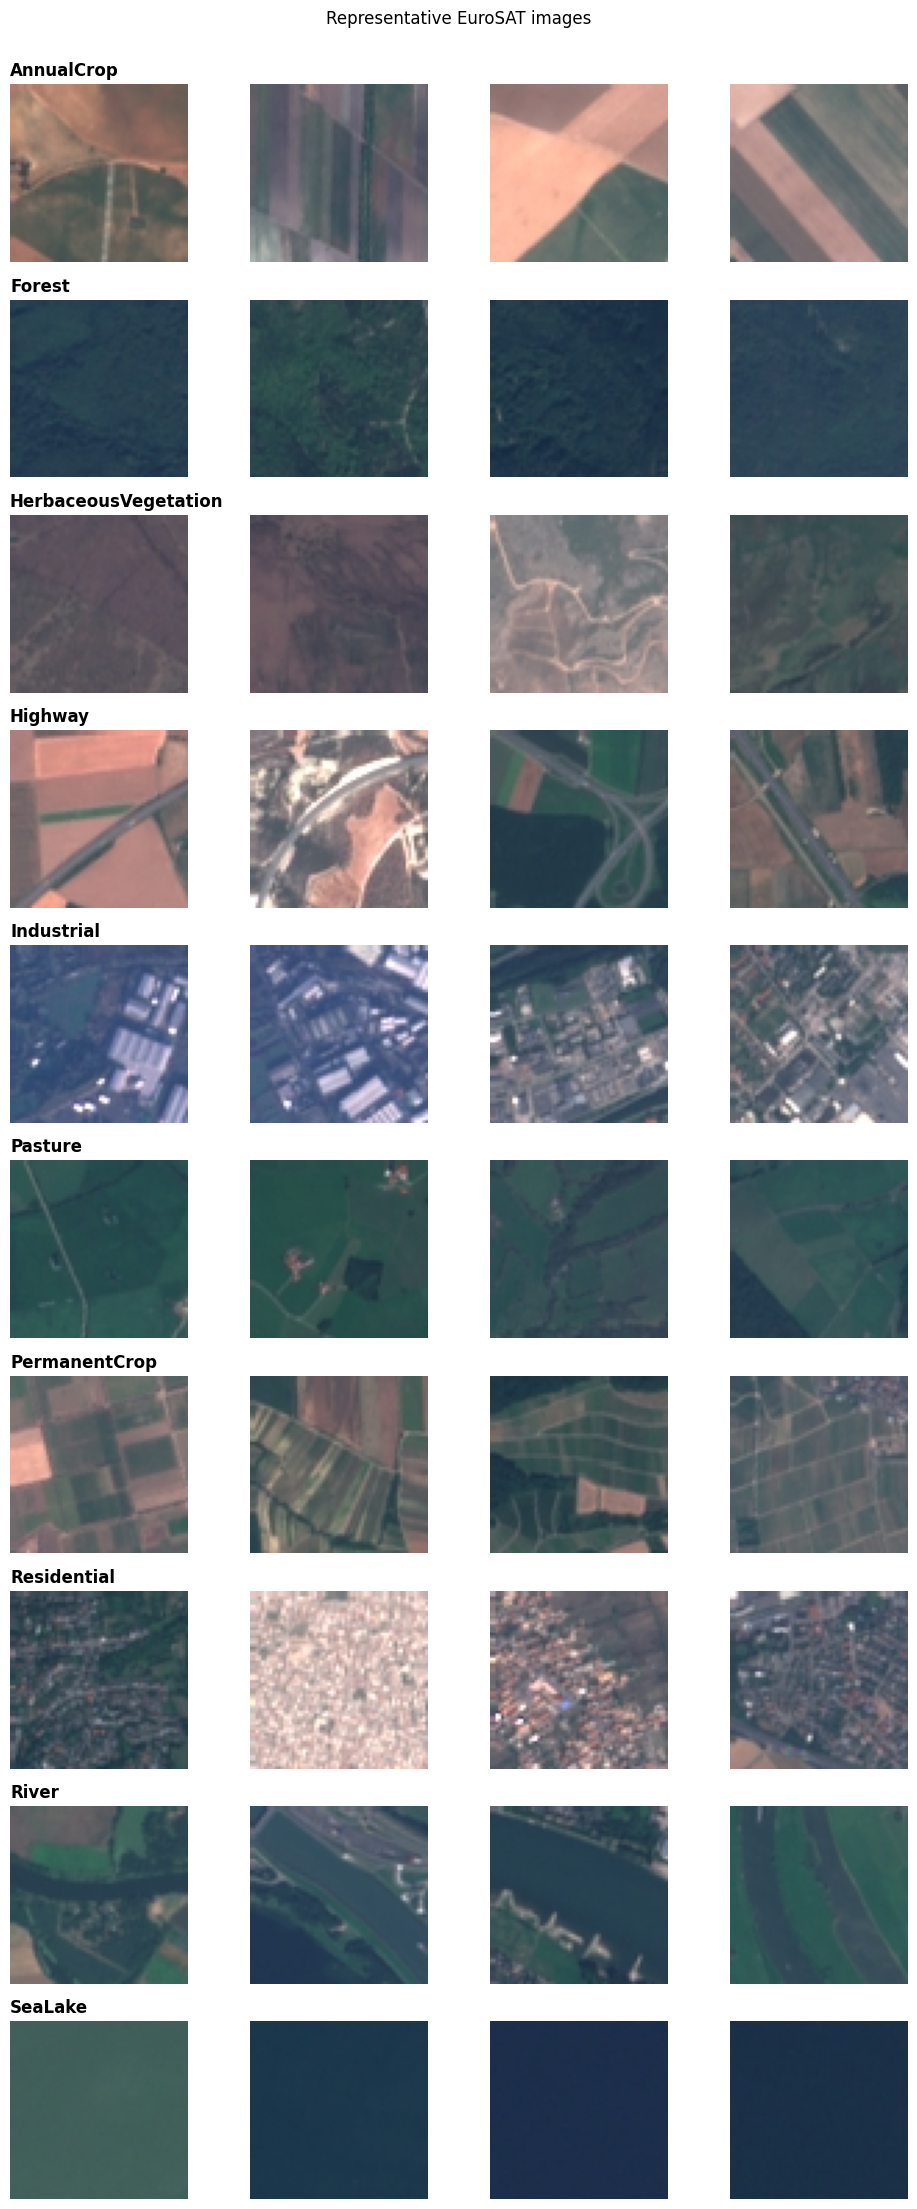

In [6]:
rng = np.random.default_rng(42)
indices_by_class = defaultdict(list)

for index, target in enumerate(dataset.targets):
    indices_by_class[target].append(index)

fig, axes = plt.subplots(
    nrows=len(dataset.classes),
    ncols=4,
    figsize=(10, 22),
)

for class_index, class_name in enumerate(dataset.classes):
    selected = rng.choice(
        indices_by_class[class_index],
        size=4,
        replace=False,
    )

    for column, image_index in enumerate(selected):
        image, _ = dataset[image_index]
        axes[class_index, column].imshow(image)
        axes[class_index, column].axis("off")

        if column == 0:
            axes[class_index, column].set_title(
                class_name,
                loc="left",
                fontweight="bold",
            )

plt.suptitle("Representative EuroSAT images", y=1.002)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "class_examples.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

The image above showcases different samples from each class 

Although we can spot the difference between different classes of EuroSAT, few of the classes look very similar to each other. Like-
Highway and River looks very similar on the first glance but on closer look we can see that the river has significantly more breath than highways. Also, River follows a more linear path in comparison to the highways. 
We can also see a huge similarity in Permanent Crop and Annual Crop classes. But upon closer inspection we can see that Permanent Crop has more defined boundaries between spaces. We can also see that Permanent Crop are more green than Annual Crop class. 
Similarities can also be found between Industrial and Residential class, but it can easily be observed that residential class has a significantly higher density.
Also, some of the labels seems very ambigous and are harder to classify into a class with certaininty, indicating that our model can be confused between such labels.

In [7]:
def extract_image_statistics(image: Image.Image) -> dict:
    array = np.asarray(image, dtype=np.float32) / 255.0
    grayscale = np.asarray(image.convert("L"), dtype=np.float32) / 255.0

    histogram, _ = np.histogram(
        grayscale,
        bins=256,
        range=(0, 1),
        density=False,
    )

    probabilities = histogram / histogram.sum()
    probabilities = probabilities[probabilities > 0]
    entropy = -(probabilities * np.log2(probabilities)).sum()

    return {
        "mean_red": float(array[:, :, 0].mean()),
        "mean_green": float(array[:, :, 1].mean()),
        "mean_blue": float(array[:, :, 2].mean()),
        "std_red": float(array[:, :, 0].std()),
        "std_green": float(array[:, :, 1].std()),
        "std_blue": float(array[:, :, 2].std()),
        "brightness": float(grayscale.mean()),
        "contrast": float(grayscale.std()),
        "entropy": float(entropy),
    }

In [8]:
records = []

for index in range(len(dataset)):
    image, target = dataset[index]
    statistics = extract_image_statistics(image)

    records.append(
        {
            "index": index,
            "class_index": target,
            "class_name": dataset.classes[target],
            **statistics,
        }
    )

features = pd.DataFrame(records)
features.to_csv(REPORTS_DIR / "image_statistics.csv", index=False)

features.head()

,index,class_index,class_name,mean_red,mean_green,mean_blue,std_red,std_green,std_blue,brightness,contrast,entropy
0,0,0,AnnualCrop,0.427878,0.382109,0.411190,0.060871,0.036548,0.027256,0.399103,0.042042,4.879012
1,1,0,AnnualCrop,0.393011,0.418318,0.373069,0.230804,0.083214,0.067411,0.405486,0.123412,5.455448
2,2,0,AnnualCrop,0.700210,0.588242,0.562894,0.147216,0.070281,0.066756,0.618760,0.092057,5.560011
3,3,0,AnnualCrop,0.601477,0.559049,0.526874,0.232093,0.116114,0.100767,0.567908,0.148350,6.522535
4,4,0,AnnualCrop,0.459737,0.454140,0.471054,0.160504,0.089461,0.075992,0.457753,0.108854,6.281175


The above block of code is computationally heavy

Time Complexity = O(NP) where
N = Number of Images : 27,000
P = Pixels per Image : 64 x 64 = 4096

In [11]:
class_statistics = (
    features
    .groupby("class_name")
    .agg(
        mean_brightness=("brightness", "mean"),
        mean_contrast=("contrast", "mean"),
        mean_entropy=("entropy", "mean"),
        mean_red=("mean_red", "mean"),
        mean_green=("mean_green", "mean"),
        mean_blue=("mean_blue", "mean"),
    )
    .round(4)
)

class_statistics

,mean_brightness,mean_contrast,mean_entropy,mean_red,mean_green,mean_blue
class_name,,,,,,
AnnualCrop,0.4806,0.0994,5.7804,0.5082,0.4707,0.4595
Forest,0.2285,0.0150,3.6984,0.1544,0.2528,0.2979
HerbaceousVegetation,0.3889,0.0618,5.6555,0.3849,0.3873,0.4076
Highway,0.3720,0.0862,5.9418,0.3452,0.3791,0.4054
Industrial,0.4934,0.1633,6.8364,0.4839,0.4918,0.5269
Pasture,0.3183,0.0377,4.9067,0.2428,0.3469,0.3693
PermanentCrop,0.4612,0.0867,6.1889,0.4789,0.4550,0.4472
Residential,0.4068,0.0812,6.1260,0.3924,0.4070,0.4432
River,0.3213,0.0753,5.3913,0.2629,0.3397,0.3800


Visual EDA begins from Now- 

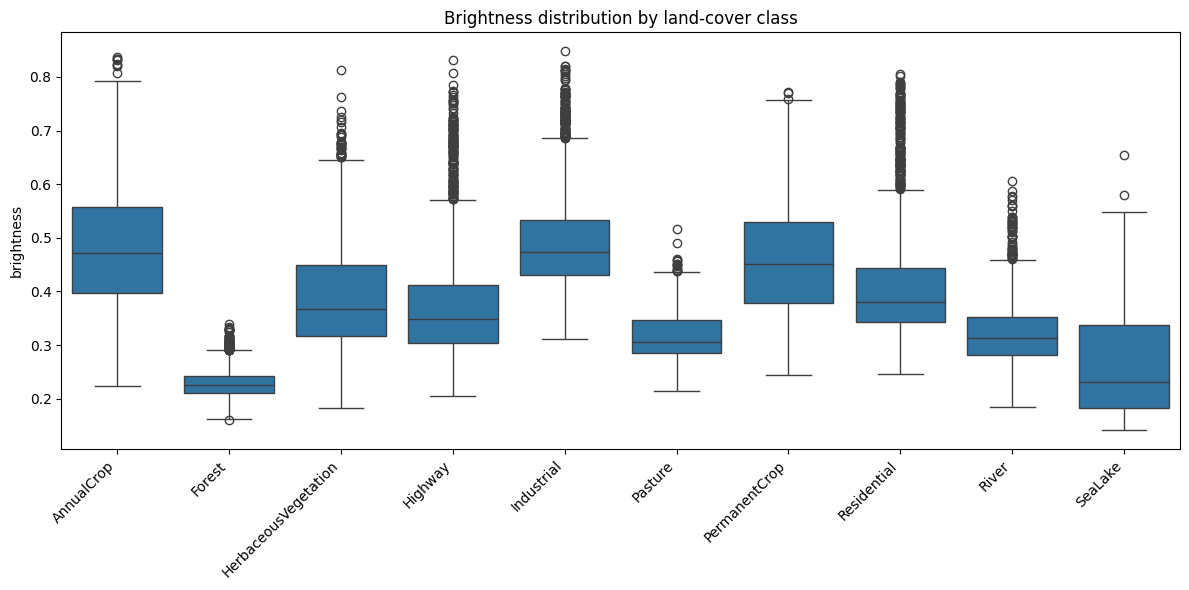

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features,
    x="class_name",
    y="brightness",
)
plt.xticks(rotation=45, ha="right")
plt.title("Brightness distribution by land-cover class")
plt.xlabel("")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "brightness_by_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

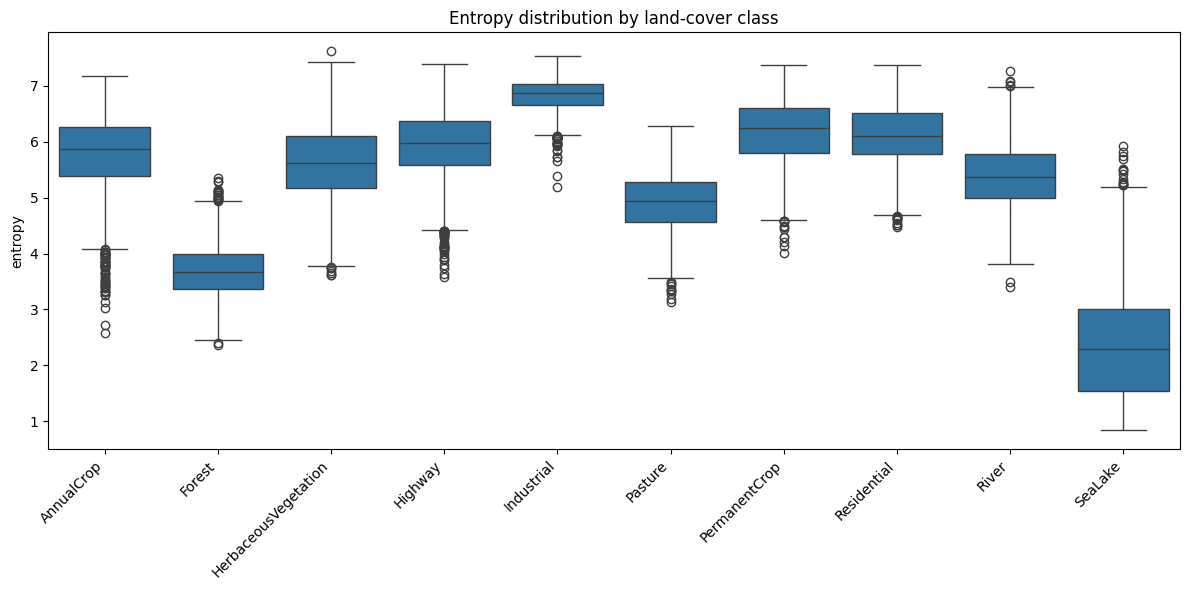

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features,
    x="class_name",
    y="entropy",
)
plt.xticks(rotation=45, ha="right")
plt.title("Entropy distribution by land-cover class")
plt.xlabel("")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "entropy_by_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [12]:
features.columns

Index(['index', 'class_index', 'class_name', 'mean_red', 'mean_green',
       'mean_blue', 'std_red', 'std_green', 'std_blue', 'brightness',
       'contrast', 'entropy'],
      dtype='object')

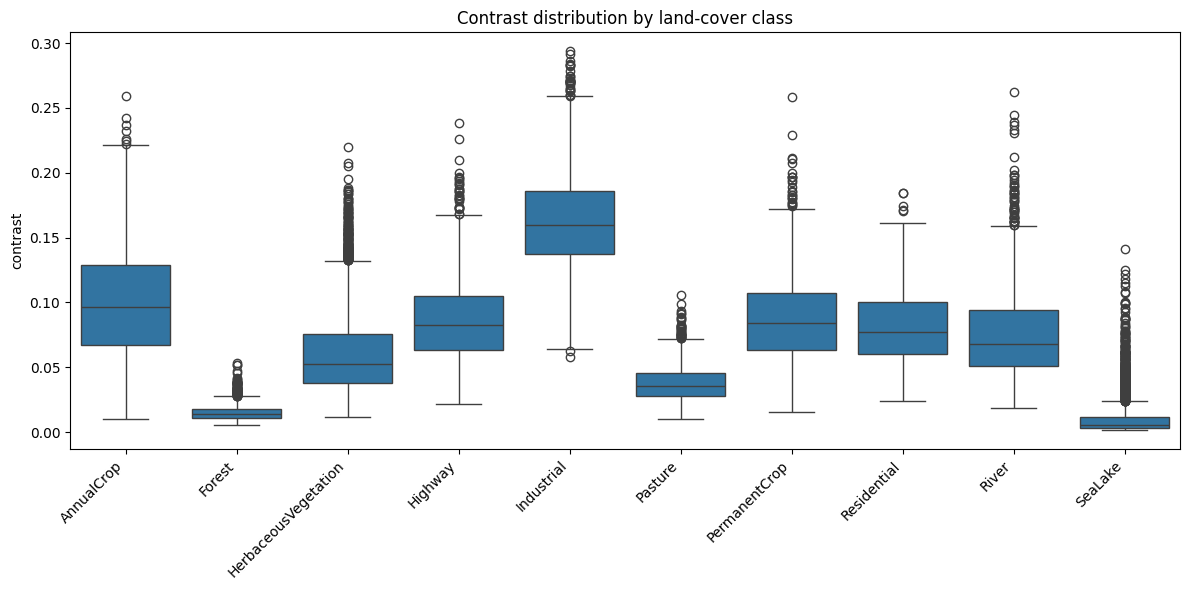

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features,
    x="class_name",
    y="contrast",
)
plt.xticks(rotation=45, ha="right")
plt.title("Contrast distribution by land-cover class")
plt.xlabel("")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "contrast_by_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

Checking for Duplicates in the Dataset

In [17]:
def md5_file(path: str | Path) -> str:
    digest = hashlib.md5()

    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(8192), b""):
            digest.update(chunk)

    return digest.hexdigest()

In [18]:
hash_records = []

for path, target in dataset.samples:
    hash_records.append(
        {
            "path": str(path),
            "class_index": target,
            "class_name": dataset.classes[target],
            "md5": md5_file(path),
        }
    )

hashes = pd.DataFrame(hash_records)

duplicate_rows = hashes[
    hashes.duplicated(subset="md5", keep=False)
].sort_values("md5")

duplicate_rows.to_csv(
    REPORTS_DIR / "duplicate_report.csv",
    index=False,
)

print("Images involved in duplicate groups:", len(duplicate_rows))
print("Unique duplicated hashes:", duplicate_rows["md5"].nunique())

Images involved in duplicate groups: 0
Unique duplicated hashes: 0


In [19]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(dataset))

train_indices, temporary_indices = train_test_split(
    indices,
    test_size=0.30,
    stratify=targets,
    random_state=42,
)

validation_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=0.50,
    stratify=targets[temporary_indices],
    random_state=42,
)

assert not set(train_indices) & set(validation_indices)
assert not set(train_indices) & set(test_indices)
assert not set(validation_indices) & set(test_indices)

assert (
    len(train_indices)
    + len(validation_indices)
    + len(test_indices)
    == len(dataset)
)

In [20]:
split_data = {
    "seed": 42,
    "method": "stratified image-level split",
    "train_fraction": 0.70,
    "validation_fraction": 0.15,
    "test_fraction": 0.15,
    "train": train_indices.tolist(),
    "validation": validation_indices.tolist(),
    "test": test_indices.tolist(),
}

with (SPLITS_DIR / "split_indices.json").open("w") as file:
    json.dump(split_data, file, indent=2)

In [21]:
audit = {
    "dataset": {
        "name": "EuroSAT RGB",
        "number_of_images": len(dataset),
        "number_of_classes": len(dataset.classes),
        "classes": dataset.classes,
        "class_to_index": dataset.class_to_idx,
        "image_mode": image.mode,
        "image_size": list(image.size),
    },
    "class_distribution": class_distribution.to_dict(orient="records"),
    "duplicates": {
        "images_in_duplicate_groups": int(len(duplicate_rows)),
        "unique_duplicate_hashes": int(
            duplicate_rows["md5"].nunique()
        ),
    },
    "split": {
        "seed": 42,
        "method": "stratified image-level",
        "train_samples": len(train_indices),
        "validation_samples": len(validation_indices),
        "test_samples": len(test_indices),
    },
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
}

with (REPORTS_DIR / "data_audit.json").open("w") as file:
    json.dump(audit, file, indent=2)

In [22]:
sample_image, sample_label = dataset[0]

assert len(dataset) == 27_000
assert len(dataset.classes) == 10
assert sample_image.mode == "RGB"
assert sample_image.size == (64, 64)
assert len(dataset.samples) == len(dataset.targets)

assert class_distribution["count"].sum() == len(dataset)
assert class_distribution["class_index"].is_unique
assert set(dataset.targets) == set(range(10))

print("All dataset integrity checks passed.")
display(class_distribution.round({"percentage": 2}))

All dataset integrity checks passed.


,class_index,class_name,count,percentage
0,0,AnnualCrop,3000,11.11
1,1,Forest,3000,11.11
2,2,HerbaceousVegetation,3000,11.11
3,3,Highway,2500,9.26
4,4,Industrial,2500,9.26
5,5,Pasture,2000,7.41
6,6,PermanentCrop,2500,9.26
7,7,Residential,3000,11.11
8,8,River,2500,9.26
9,9,SeaLake,3000,11.11


In [23]:
numeric_features = [
    "mean_red",
    "mean_green",
    "mean_blue",
    "std_red",
    "std_green",
    "std_blue",
    "brightness",
    "contrast",
    "entropy",
]

feature_quality = pd.DataFrame({
    "missing": features[numeric_features].isna().sum(),
    "non_finite": [
        (~np.isfinite(features[column])).sum()
        for column in numeric_features
    ],
    "minimum": features[numeric_features].min(),
    "maximum": features[numeric_features].max(),
})

assert feature_quality["missing"].sum() == 0
assert feature_quality["non_finite"].sum() == 0

display(feature_quality.round(4))

,missing,non_finite,minimum,maximum
mean_red,0,0,0.0874,0.9952
mean_green,0,0,0.1488,0.8209
mean_blue,0,0,0.2239,0.8019
std_red,0,0,0.0018,0.3572
std_green,0,0,0.0024,0.2797
std_blue,0,0,0.0028,0.2737
brightness,0,0,0.1417,0.8477
contrast,0,0,0.0017,0.2937
entropy,0,0,0.8416,7.6204


In [24]:
channel_names = ["red", "green", "blue"]

channel_means = np.array([
    features["mean_red"].mean(),
    features["mean_green"].mean(),
    features["mean_blue"].mean(),
])

# E[X²] = Var(X) + E[X]²
channel_second_moments = np.array([
    np.mean(features["std_red"] ** 2 + features["mean_red"] ** 2),
    np.mean(features["std_green"] ** 2 + features["mean_green"] ** 2),
    np.mean(features["std_blue"] ** 2 + features["mean_blue"] ** 2),
])

channel_stds = np.sqrt(
    channel_second_moments - channel_means ** 2
)

normalization_statistics = pd.DataFrame({
    "channel": channel_names,
    "mean": channel_means,
    "standard_deviation": channel_stds,
})

display(normalization_statistics.round(4))

,channel,mean,standard_deviation
0,red,0.3444,0.2027
1,green,0.3803,0.1369
2,blue,0.4078,0.1156


In [25]:
torchvision.transforms.Normalize(
    mean=channel_means.tolist(),
    std=channel_stds.tolist(),
)

Normalize(mean=[0.3443759709500052, 0.3802908512254556, 0.40777029817799726], std=[0.20266077405089558, 0.1368965927893031, 0.11555012193413014])

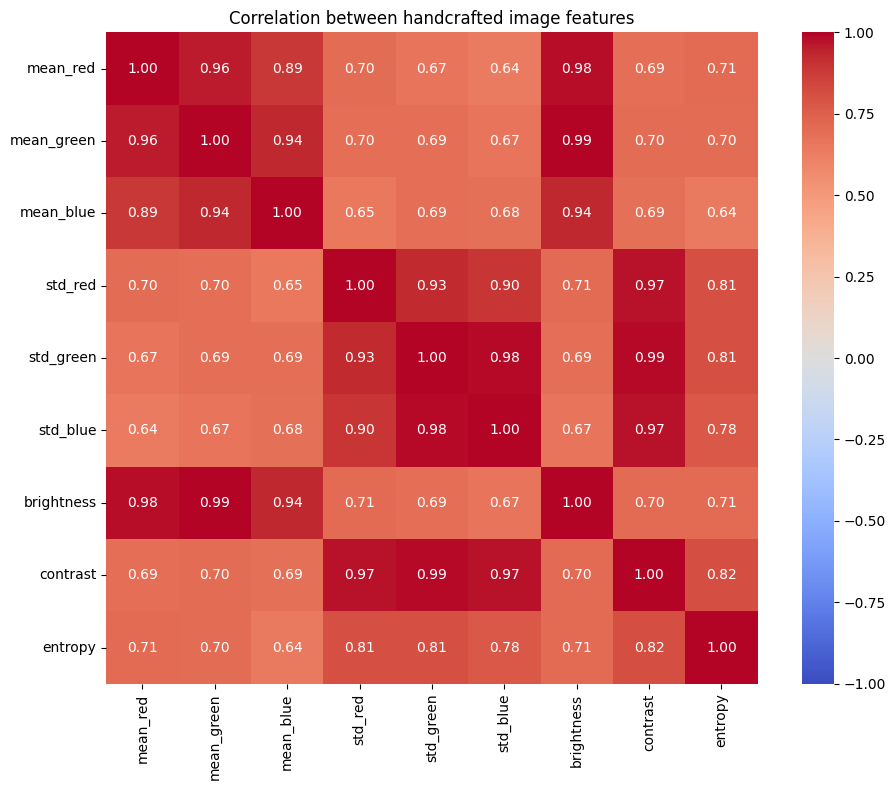

In [26]:
feature_correlations = features[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    feature_correlations,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax,
)

ax.set_title("Correlation between handcrafted image features")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "feature_correlations.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [27]:
split_indices = {
    "train": train_indices,
    "validation": validation_indices,
    "test": test_indices,
}

split_distribution_records = []

for split_name, split_index in split_indices.items():
    split_targets = targets[split_index]
    split_counts = Counter(split_targets)

    for class_index, class_name in enumerate(dataset.classes):
        count = split_counts[class_index]

        split_distribution_records.append({
            "split": split_name,
            "class_index": class_index,
            "class_name": class_name,
            "count": count,
            "percentage_within_split": (
                100 * count / len(split_index)
            ),
        })

split_distribution = pd.DataFrame(
    split_distribution_records
)

display(
    split_distribution.pivot(
        index="class_name",
        columns="split",
        values="count",
    )
)

split_distribution.to_csv(
    REPORTS_DIR / "split_class_distribution.csv",
    index=False,
)

split,test,train,validation
class_name,,,
AnnualCrop,450,2100,450
Forest,450,2100,450
HerbaceousVegetation,450,2100,450
Highway,375,1750,375
Industrial,375,1750,375
Pasture,300,1400,300
PermanentCrop,375,1750,375
Residential,450,2100,450
River,375,1750,375


In [28]:
def create_split_manifest(split_name, split_index):
    rows = []

    for index in split_index:
        path, class_index = dataset.samples[index]

        rows.append({
            "dataset_index": int(index),
            "relative_path": Path(path).relative_to(
                DATA_ROOT
            ).as_posix(),
            "class_name": dataset.classes[class_index],
            "class_index": int(class_index),
            "split": split_name,
        })

    return pd.DataFrame(rows)


for split_name, split_index in split_indices.items():
    manifest = create_split_manifest(
        split_name,
        split_index,
    )

    manifest.to_csv(
        SPLITS_DIR / f"{split_name}.csv",
        index=False,
    )

In [29]:
split_file = SPLITS_DIR / "split_indices.json"
split_checksum = md5_file(split_file)

print("Split checksum:", split_checksum)

with (SPLITS_DIR / "split_indices.md5").open("w") as file:
    file.write(f"{split_checksum}  split_indices.json\n")

Split checksum: f97c4ec9a27435a932662d5a8b707255


## Initial EDA findings

- EuroSAT RGB contains 27,000 images across 10 classes.
- Class sizes range from 2,000 to 3,000 images, producing a modest
  maximum-to-minimum imbalance ratio of 1.5:1. Weighted loss is not
  initially justified, but macro-F1 will be reported.
- No exact file duplicates were detected using MD5 hashes.
- Forest and Sea/Lake images are generally darker and have substantially
  lower contrast than built-environment classes.
- Industrial images have the highest average brightness, contrast and
  entropy, indicating greater local visual complexity.
- Sea/Lake has the lowest entropy and contrast, consistent with its
  comparatively uniform image content.
- Likely difficult distinctions include Annual Crop vs Permanent Crop,
  Highway vs River, and Industrial vs Residential.
- Handcrafted colour and texture variables show useful class separation,
  but their distributions overlap. Therefore, they provide a meaningful
  statistical baseline rather than a complete classification solution.

## Evaluation limitation

The project uses a fixed stratified image-level split. Geographic
grouping metadata is not incorporated. Results therefore estimate
performance on held-out EuroSAT images and must not be interpreted as
generalization to completely unseen geographic regions.

## Data provenance

- Dataset: EuroSAT RGB
- Samples: 27,000
- Classes: 10
- Resolution: 64 × 64 RGB
- Source: official EuroSAT release by Helber et al.
- DOI: 10.5281/zenodo.7711097